Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

from src.audio import load_example_audio, load_audio_file
from src.preprocessing import preprocess_audio
from src.visualization import plot_frequency_spectrum, plot_psd, compute_band_power, plot_filterbank_waveforms, plot_filterbank_psd, plot_envelopes
from src.filterbank import apply_filterbank
from src.envelope import full_wave_rectify,extract_envelopes
from src.compression import compress_envelopes


Audio

22050 (176400,)
22050 (176400,)
Speech:


Music:


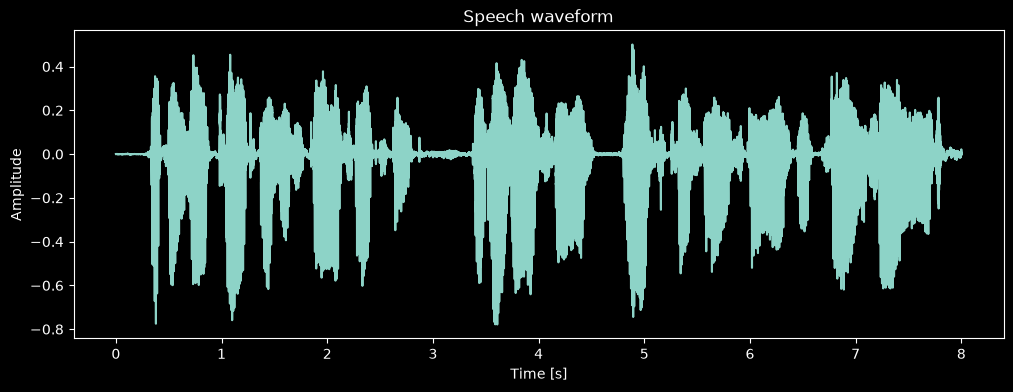

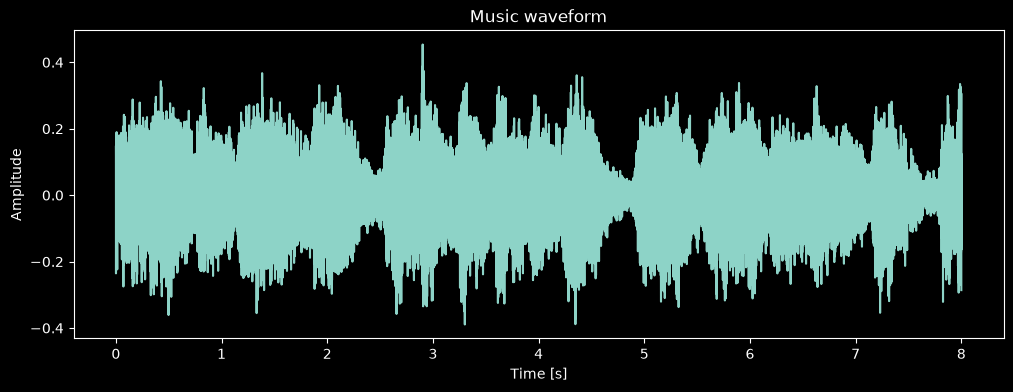

In [2]:
speech, fs_speech = load_example_audio(
    "libri1",
    sr=22050,
    duration=8.0
)

music, fs_music = load_example_audio(
    "brahms",
    sr=22050,
    duration=8.0,
    offset=15.0
)

print(fs_speech, speech.shape)
print(fs_music, music.shape)

print("Speech:")
display(Audio(speech, rate=fs_speech))

print("Music:")
display(Audio(music, rate=fs_music))

time_speech = np.arange(len(speech)) / fs_speech
time_music = np.arange(len(music)) / fs_music

plt.figure(figsize=(12, 4))
plt.plot(time_speech, speech)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Speech waveform")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(time_music, music)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Music waveform")
plt.show()

Preprocessing

In [3]:
speech_processed = preprocess_audio(speech)
music_processed = preprocess_audio(music)

print("Speech")
print("Mean before:", np.mean(speech))
print("Mean after :", np.mean(speech_processed))
print("Peak after :", np.max(np.abs(speech_processed)))

print("\nMusic")
print("Mean before:", np.mean(music))
print("Mean after :", np.mean(music_processed))
print("Peak after :", np.max(np.abs(music_processed)))

from IPython.display import Audio, display

print("Original speech:")
display(Audio(speech, rate=fs_speech))

print("Processed speech:")
display(Audio(speech_processed, rate=fs_speech))

Speech
Mean before: 7.842776e-05
Mean after : 2.7031585e-10
Peak after : 1.0

Music
Mean before: -3.5933706e-05
Mean after : -1.056935e-09
Peak after : 1.0
Original speech:


Processed speech:


Visualization

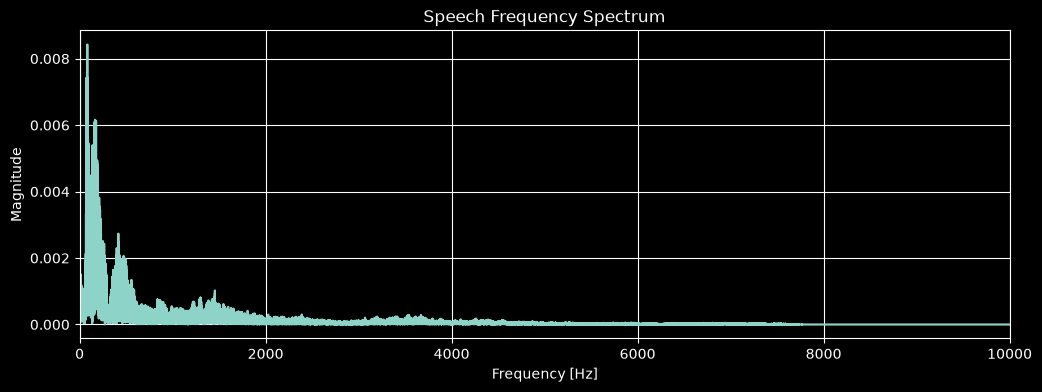

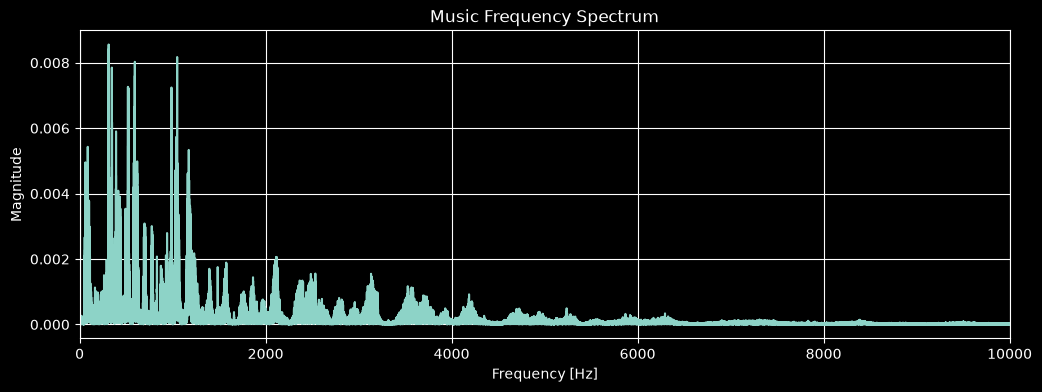

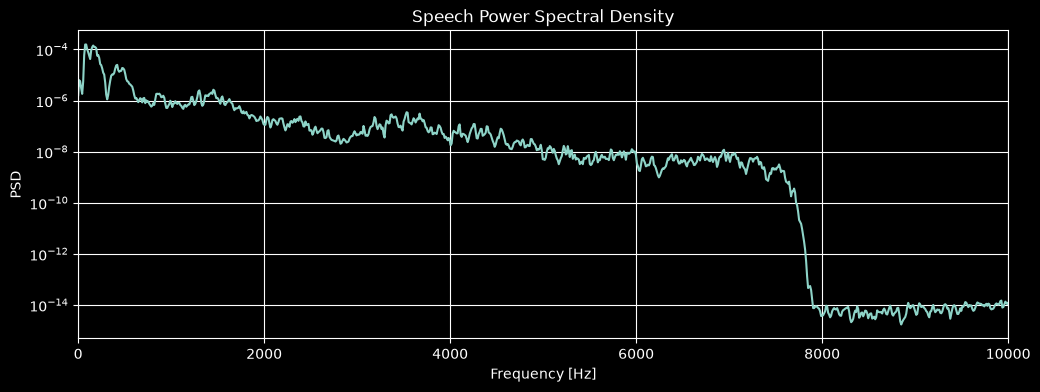

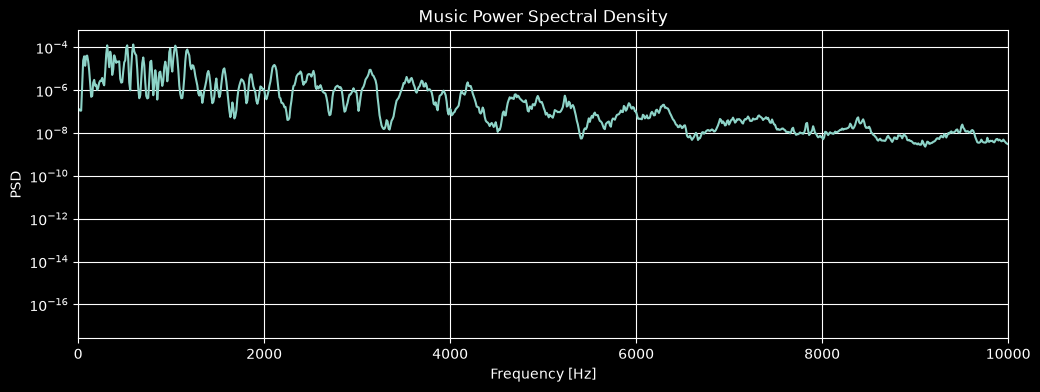

Band [Hz]           Speech [%]   Music [%]
------------------------------------------
200-500                  71.30       19.45
500-1250                 15.66       61.74
1250-3150                10.70       13.75
3150-8000                 2.35        5.06


In [4]:
plot_frequency_spectrum(
    speech_processed,
    fs_speech,
    title="Speech Frequency Spectrum",
    max_freq=10000
)

plot_frequency_spectrum(
    music_processed,
    fs_music,
    title="Music Frequency Spectrum",
    max_freq=10000
)


plot_psd(
    speech_processed,
    fs_speech,
    title="Speech Power Spectral Density"
)

plot_psd(
    music_processed,
    fs_music,
    title="Music Power Spectral Density"
)


band_edges = [200, 500, 1250, 3150, 8000]

speech_band_power = compute_band_power(
    speech_processed,
    fs_speech,
    band_edges
)

music_band_power = compute_band_power(
    music_processed,
    fs_music,
    band_edges
)

print(f"{'Band [Hz]':<18}{'Speech [%]':>12}{'Music [%]':>12}")
print("-" * 42)

for i in range(len(band_edges) - 1):
    band = f"{band_edges[i]}-{band_edges[i+1]}"

    print(
        f"{band:<18}"
        f"{speech_band_power[i]:>12.2f}"
        f"{music_band_power[i]:>12.2f}"
    )

Band-pass Filtering

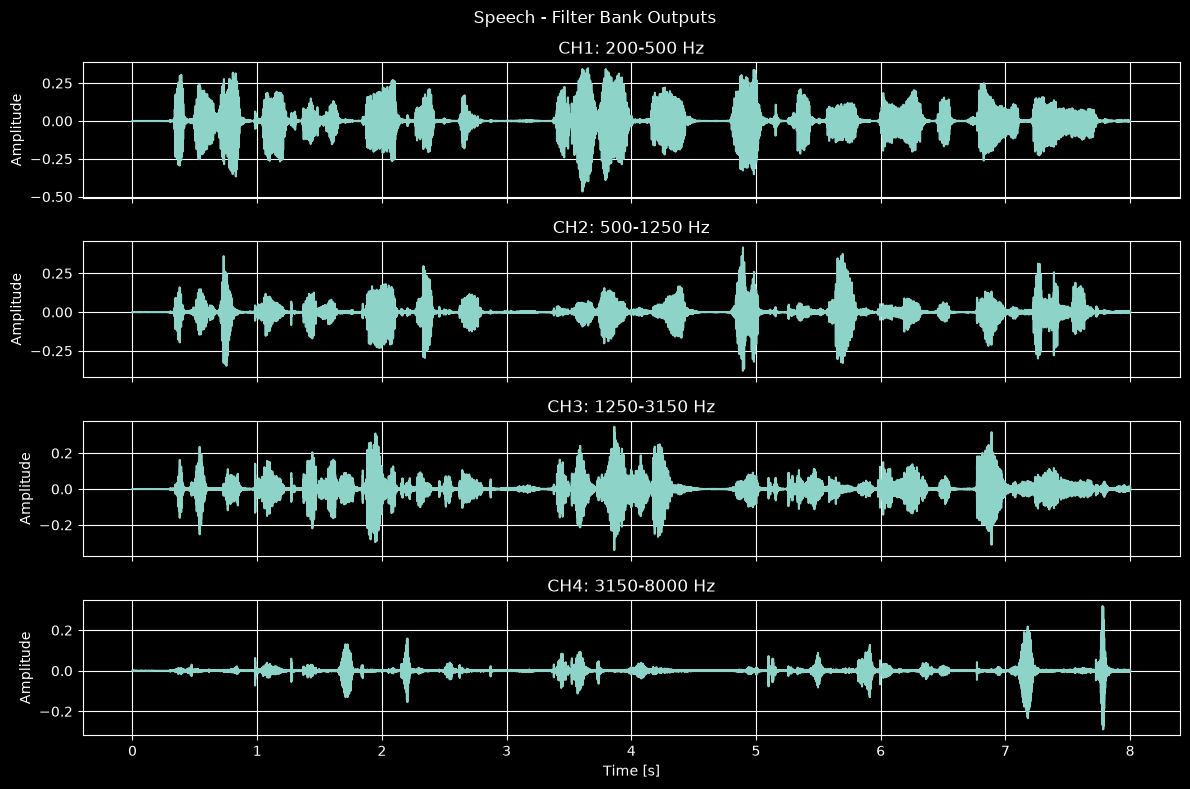

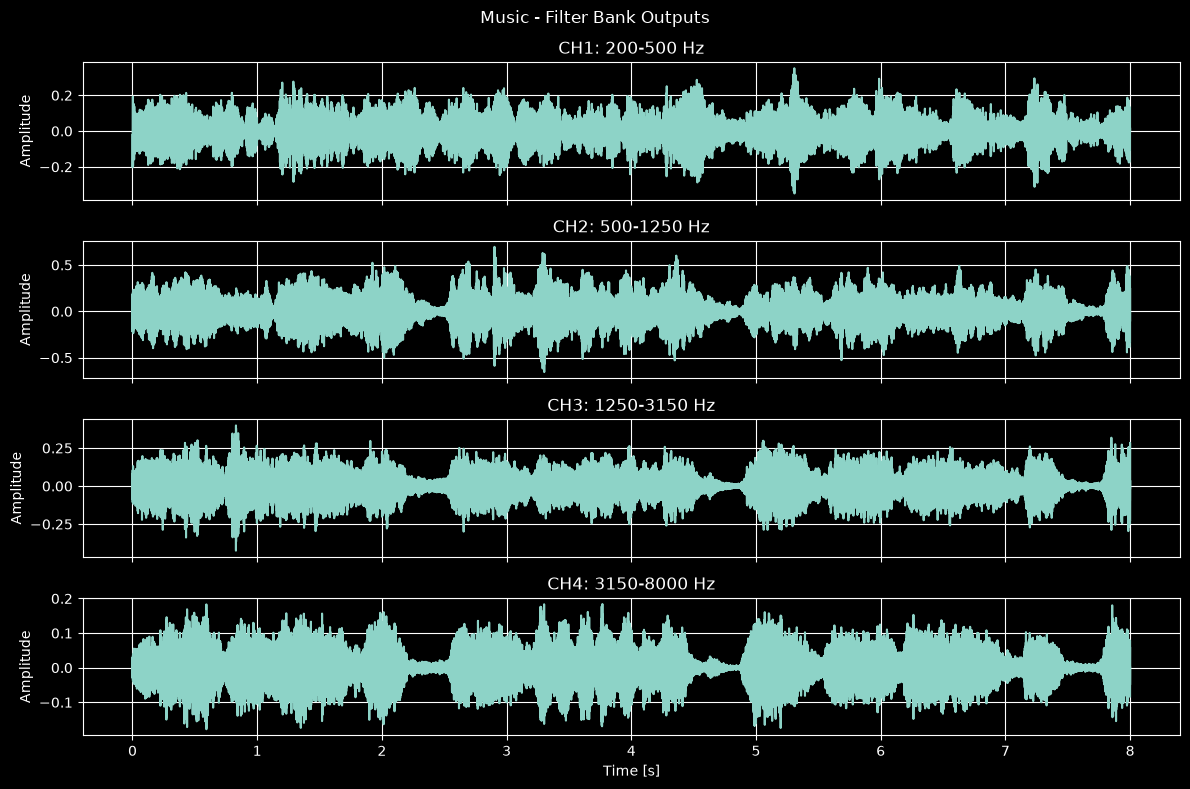

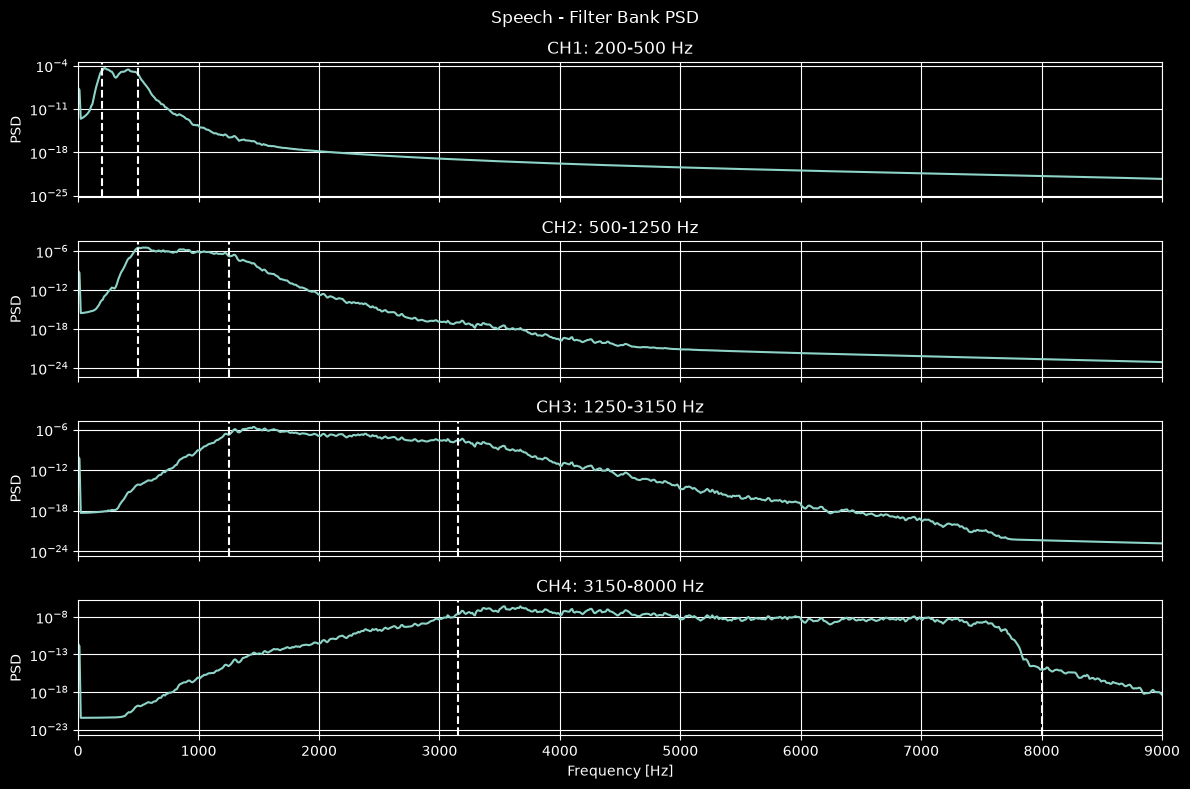

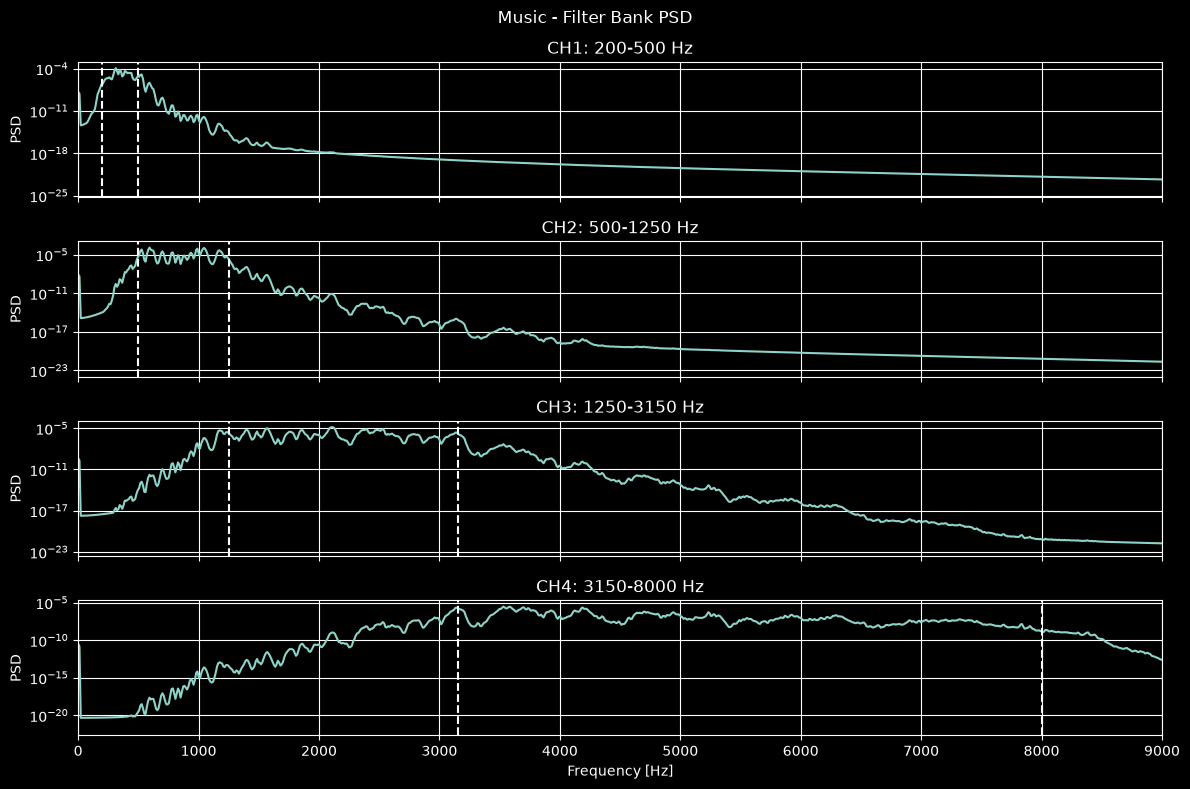

In [5]:
band_edges = [200, 500, 1250, 3150, 8000]

speech_channels = apply_filterbank(
    speech_processed,
    fs_speech,
    band_edges
)

music_channels = apply_filterbank(
    music_processed,
    fs_music,
    band_edges
)

plot_filterbank_waveforms(
    speech_channels,
    fs_speech,
    band_edges,
    title="Speech - Filter Bank Outputs"
)

plot_filterbank_waveforms(
    music_channels,
    fs_music,
    band_edges,
    title="Music - Filter Bank Outputs"
)

plot_filterbank_psd(
    speech_channels,
    fs_speech,
    band_edges,
    title="Speech - Filter Bank PSD"
)

plot_filterbank_psd(
    music_channels,
    fs_music,
    band_edges,
    title="Music - Filter Bank PSD"
)

Envelope extraction

Envelope ranges before compression

Speech
CH1: min=0.000000, max=0.316832
CH2: min=0.000000, max=0.244291
CH3: min=0.000000, max=0.221613
CH4: min=0.000000, max=0.141306

Music
CH1: min=0.000329, max=0.229571
CH2: min=0.000822, max=0.381536
CH3: min=0.001228, max=0.217649
CH4: min=0.000318, max=0.096334


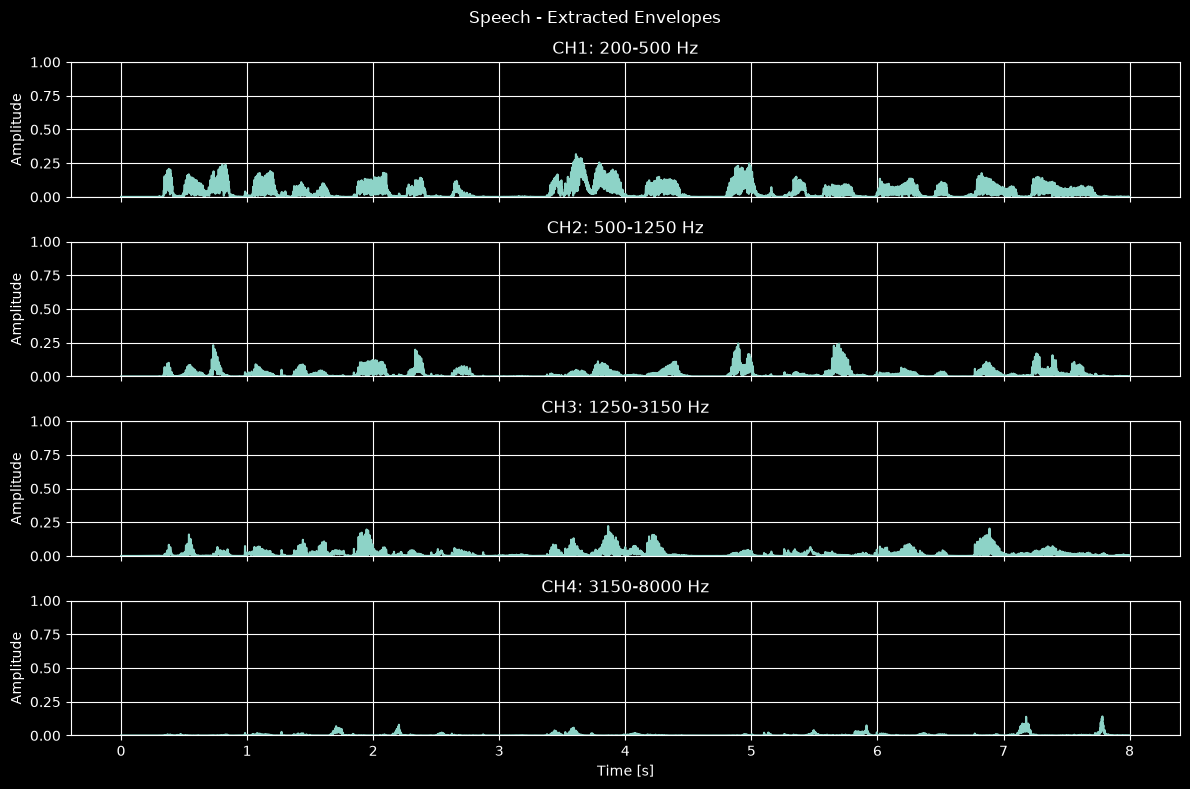

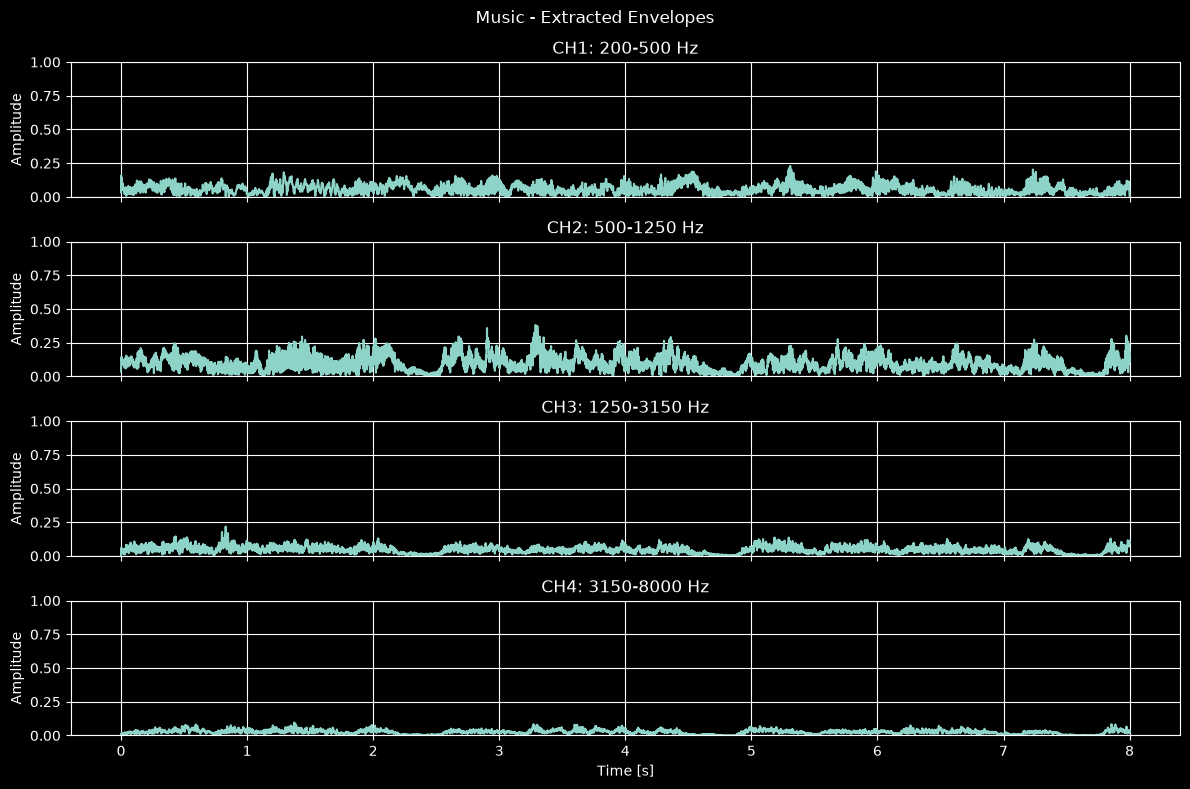

In [6]:
speech_envelopes = extract_envelopes(
    speech_channels,
    fs_speech,
    cutoff=400
)

music_envelopes = extract_envelopes(
    music_channels,
    fs_music,
    cutoff=400
)

print("Envelope ranges before compression")

for name, envelopes in [
    ("Speech", speech_envelopes),
    ("Music", music_envelopes)
]:
    print(f"\n{name}")

    for i, env in enumerate(envelopes):
        print(
            f"CH{i+1}: "
            f"min={np.min(env):.6f}, "
            f"max={np.max(env):.6f}"
        )

assert all(
    np.all((env >= 0) & (env <= 1))
    for env in speech_envelopes + music_envelopes
)

channel_index = 0

channel = speech_channels[channel_index]
rectified = full_wave_rectify(channel)
envelope = speech_envelopes[channel_index]

start_time = 3.5
end_time = 4.0

start_sample = int(start_time * fs_speech)
end_sample = int(end_time * fs_speech)

time = np.arange(start_sample, end_sample) / fs_speech

plot_envelopes(
    speech_envelopes,
    fs_speech,
    band_edges,
    title="Speech - Extracted Envelopes"
)

plot_envelopes(
    music_envelopes,
    fs_music,
    band_edges,
    title="Music - Extracted Envelopes"
)

Logarithmic compression

Compressed envelope ranges

Speech
CH1: min=0.000000, max=0.833945
CH2: min=0.000000, max=0.796445
CH3: min=0.000000, max=0.782404
CH4: min=0.000000, max=0.717637

Music
CH1: min=0.041199, max=0.787488
CH2: min=0.086810, max=0.860766
CH3: min=0.115946, max=0.779803
CH4: min=0.039935, max=0.662659


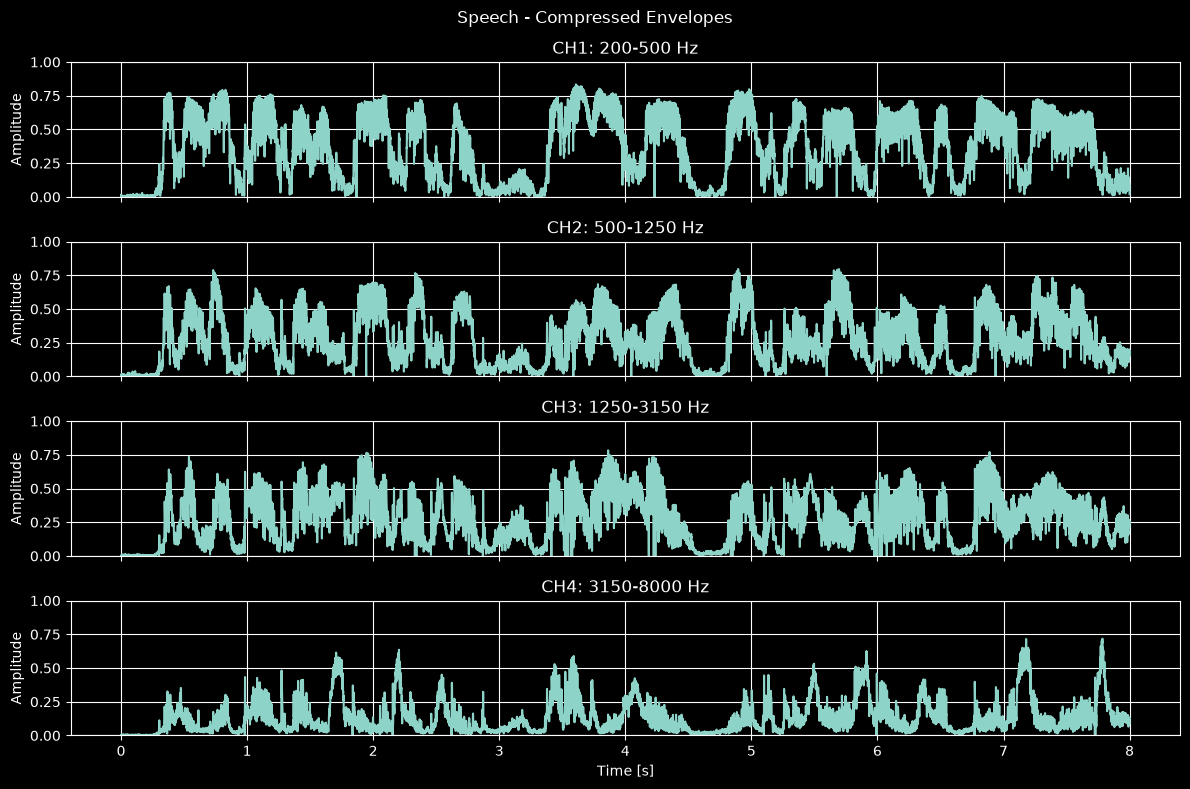

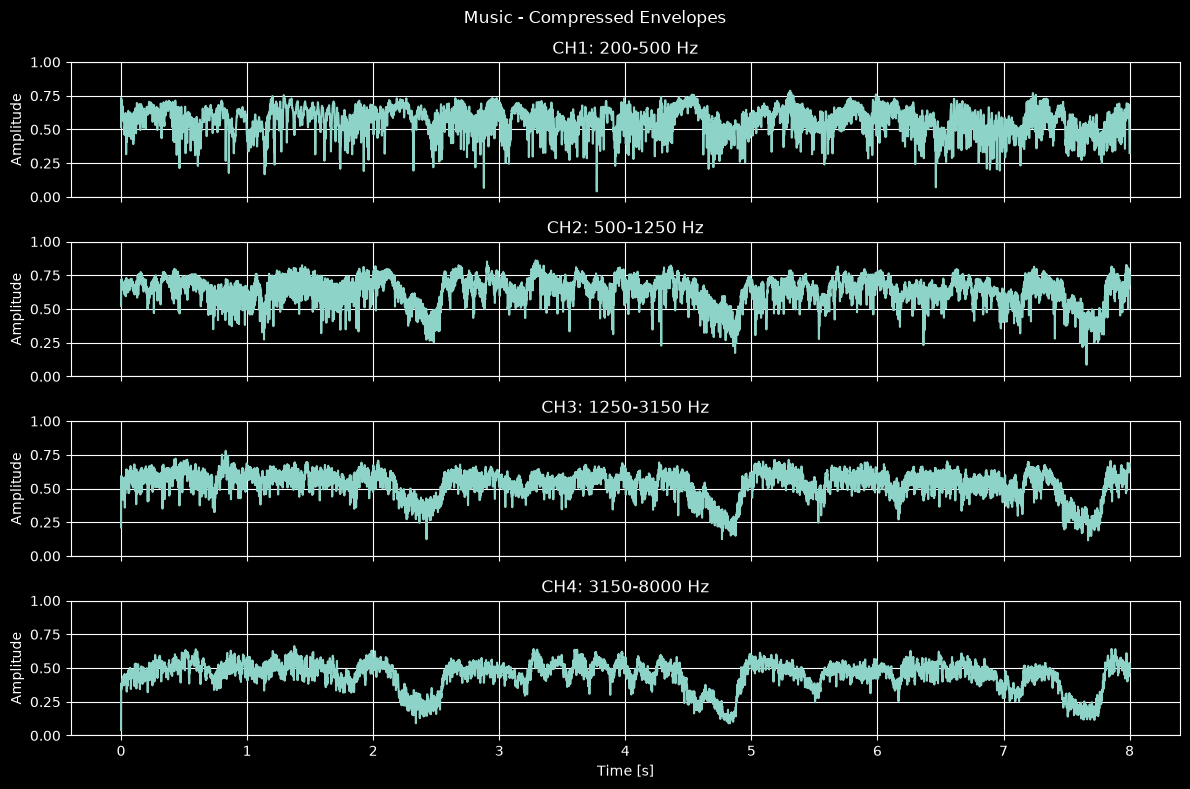

In [7]:
alpha = 1000.0

speech_compressed_envelopes = compress_envelopes(
    speech_envelopes,
    alpha=alpha
)

music_compressed_envelopes = compress_envelopes(
    music_envelopes,
    alpha=alpha
)

print("Compressed envelope ranges")

for name, envelopes in [
    ("Speech", speech_compressed_envelopes),
    ("Music", music_compressed_envelopes)
]:
    print(f"\n{name}")

    for i, env in enumerate(envelopes):
        print(
            f"CH{i+1}: "
            f"min={np.min(env):.6f}, "
            f"max={np.max(env):.6f}"
        )

assert all(
    np.all((env >= 0) & (env <= 1))
    for env in speech_compressed_envelopes + music_compressed_envelopes
)

plot_envelopes(
    speech_compressed_envelopes,
    fs_speech,
    band_edges,
    title="Speech - Compressed Envelopes"
)

plot_envelopes(
    music_compressed_envelopes,
    fs_music,
    band_edges,
    title="Music - Compressed Envelopes"
)